# House Price Prediction - ML Model 

## 1. Import Libraries 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

## 2. Load and Explore Data

In [2]:
df = pd.read_csv("house_prices.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128 entries, 0 to 127
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Home             128 non-null    int64 
 1   Price            128 non-null    int64 
 2   Size             128 non-null    int64 
 3   Bedrooms         128 non-null    int64 
 4   Bathrooms        128 non-null    int64 
 5   Number of Rooms  128 non-null    int64 
 6   Offers           128 non-null    int64 
 7   Brick            128 non-null    object
 8   Location         128 non-null    object
dtypes: int64(7), object(2)
memory usage: 9.1+ KB


In [4]:
df.head()

,Home,Price,Size,Bedrooms,Bathrooms,Number of Rooms,Offers,Brick,Location
0,1,114300,1790,2,2,4,2,No,East
1,2,114200,2030,4,2,6,3,No,East
2,3,114800,1740,3,2,5,1,No,East
3,4,94700,1980,3,2,5,3,No,East
4,5,119800,2130,3,3,6,3,No,East


In [5]:
df.shape

(128, 9)

In [7]:
df.describe()

,Home,Price,Size,Bedrooms,Bathrooms,Number of Rooms,Offers
count,128.000000,128.000000,128.000000,128.000000,128.000000,128.000000,128.000000
mean,64.500000,130427.343750,2000.937500,3.023438,2.445312,5.468750,2.578125
std,37.094474,26868.770371,211.572431,0.725951,0.514492,1.049466,1.069324
min,1.000000,69100.000000,1450.000000,2.000000,2.000000,4.000000,1.000000
25%,32.750000,111325.000000,1880.000000,3.000000,2.000000,5.000000,2.000000
50%,64.500000,125950.000000,2000.000000,3.000000,2.000000,5.000000,3.000000
75%,96.250000,148250.000000,2140.000000,3.000000,3.000000,6.000000,3.000000
max,128.000000,211200.000000,2590.000000,5.000000,4.000000,9.000000,6.000000


In [8]:
# Check for missing values 
df.isnull().sum()

Home               0
Price              0
Size               0
Bedrooms           0
Bathrooms          0
Number of Rooms    0
Offers             0
Brick              0
Location           0
dtype: int64

In [10]:
# Fill missing numerical values with median
df["Size"].fillna(df["Size"].median(), inplace=True)
df["Number of Rooms"].fillna(df["Number of Rooms"].median(), inplace=True)
df["Price"].fillna(df["Price"].median(), inplace=True)

# Fill missing categorical values with mode
df["Location"].fillna(df["Location"].mode()[0], inplace=True)

In [11]:
# Check distribution of numerical variables using descriptive statistics
print(df[["Size", "Number of Rooms", "Price"]].describe())

# Identify potential outliers using IQR (Interquartile Range)
Q1 = df[["Size", "Number of Rooms", "Price"]].quantile(0.25)
Q3 = df[["Size", "Number of Rooms", "Price"]].quantile(0.75)
IQR = Q3 - Q1

# Define outlier boundaries
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers = ((df[["Size", "Number of Rooms", "Price"]] < lower_bound) | 
            (df[["Size", "Number of Rooms", "Price"]] > upper_bound))

# Count outliers in each column
print(outliers.sum())

              Size  Number of Rooms          Price
count   128.000000       128.000000     128.000000
mean   2000.937500         5.468750  130427.343750
std     211.572431         1.049466   26868.770371
min    1450.000000         4.000000   69100.000000
25%    1880.000000         5.000000  111325.000000
50%    2000.000000         5.000000  125950.000000
75%    2140.000000         6.000000  148250.000000
max    2590.000000         9.000000  211200.000000
Size               2
Number of Rooms    2
Price              1
dtype: int64


# 3. Data Preprocessing

In [12]:
# Normalize Numerical Data
scaler = MinMaxScaler()
df[["Size", "Number of Rooms"]] = scaler.fit_transform(df[["Size", "Number of Rooms"]])
df.head() # Check transformed values

,Home,Price,Size,Bedrooms,Bathrooms,Number of Rooms,Offers,Brick,Location
0,1,114300,0.298246,2,2,0.0,2,No,East
1,2,114200,0.508772,4,2,0.4,3,No,East
2,3,114800,0.254386,3,2,0.2,1,No,East
3,4,94700,0.464912,3,2,0.2,3,No,East
4,5,119800,0.596491,3,3,0.4,3,No,East


In [13]:
# One-Hot Encoding for Location
df = pd.get_dummies(df, columns=["Location"], drop_first=True)

df.head()  # Check encoded columns

,Home,Price,Size,Bedrooms,Bathrooms,Number of Rooms,Offers,Brick,Location_North,Location_West
0,1,114300,0.298246,2,2,0.0,2,No,0,0
1,2,114200,0.508772,4,2,0.4,3,No,0,0
2,3,114800,0.254386,3,2,0.2,1,No,0,0
3,4,94700,0.464912,3,2,0.2,3,No,0,0
4,5,119800,0.596491,3,3,0.4,3,No,0,0


# 4. Feature Selection 

### 4.1 Analyze Correlations

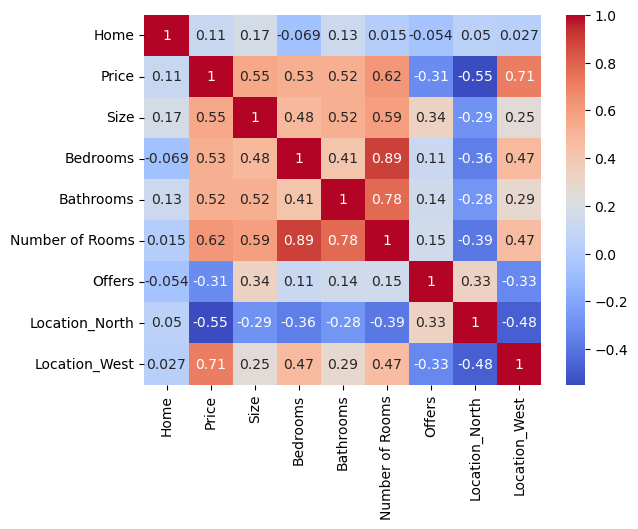

Price              1.000000
Location_West      0.714007
Number of Rooms    0.620324
Size               0.552982
Bedrooms           0.525926
Bathrooms          0.523258
Home               0.108190
Offers            -0.313636
Location_North    -0.548221
Name: Price, dtype: float64


In [14]:
# Correlation matrix
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm")
plt.show()

# Check correlation with target variable (Price)
print(correlation_matrix["Price"].sort_values(ascending=False))

# 5. Model Training

### 5.1 Train-Test Split

In [24]:
# Define features and target variable
X = df.drop(columns=['Price'])# All features except target
y = df["Price"]  # Target variable

# Split the dataset (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape, X_test.shape)  # Verify split

(102, 9) (26, 9)


In [ ]:
X_train = X_train.drop(columns= ['Brick'])

In [30]:
X_test = X_test.drop(columns= ['Brick'])

In [31]:
X_test.head()

,Home,Size,Bedrooms,Bathrooms,Number of Rooms,Offers,Location_North,Location_West
55,56,0.236842,2,2,0.0,2,0,0
40,41,0.096491,2,2,0.0,1,0,0
19,20,0.412281,3,3,0.4,2,0,1
31,32,0.421053,2,2,0.0,2,1,0
98,99,0.535088,3,2,0.2,1,0,1


### 5.2 Train a Linear Regression Model

In [32]:
model = LinearRegression()
model.fit(X_train, y_train)

# Display model coefficients
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)
print(X_train.head())

Coefficients: [-4.55088863e+00  6.68625124e+04  2.51657302e+03  9.48374216e+03
  2.40006304e+03 -9.09013861e+03 -2.69821313e+03  2.20610838e+04]
Intercept: 84203.5248650598
    Home      Size  Bedrooms  Bathrooms  Number of Rooms  Offers  \
70    71  0.438596         3          3              0.4       3   
78    79  0.596491         3          2              0.2       3   
47    48  0.526316         3          2              0.2       6   
0      1  0.298246         2          2              0.0       2   
12    13  0.403509         3          2              0.2       4   

    Location_North  Location_West  
70               0              1  
78               1              0  
47               1              0  
0                0              0  
12               1              0  


# 6. Model Evaluation

In [33]:
# Make predictions
y_pred = model.predict(X_test)

# Calculate RMSE
rmse = mean_squared_error(y_test, y_pred, squared=False)
print("RMSE:", rmse)

# Calculate R² Score
r2 = r2_score(y_test, y_pred)
print("R² Score:", r2)

RMSE: 14466.755586726902
R² Score: 0.6449144703733745


C:\Users\Harshitha R\AppData\Roaming\Python\Python39\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


**Conclusion**

In this project, we developed a linear regression model to predict house prices using a dataset containing key features such as the size of the house, its location, and the number of rooms. The process involved several crucial steps, each of which contributed to ensuring the quality of our predictions.

1. **Data Exploration and Cleaning:**  
   We began by loading the dataset and performing exploratory data analysis. This included checking for missing values and analyzing the distribution of numerical features. Outliers were identified using statistical measures like the interquartile range (IQR), ensuring that our model wouldn’t be unduly influenced by anomalous data points. Cleaning the data by imputing missing values (using median for numerical variables and mode for categorical ones) was a key step in preparing the data for modeling.

2. **Data Preprocessing:**  
   To ensure all features were comparable, numerical variables such as size and the number of rooms were normalized using Min-Max scaling. Additionally, the categorical variable (Location) was transformed into a numerical format through one-hot encoding. This conversion was essential because linear regression models require all input features to be numeric. By applying these preprocessing techniques, we ensured that the model could learn effectively from the data.

3. **Feature Selection:**  
   We used correlation analysis to assess the relationship between each predictor and the target variable, Price. This step provided valuable insights into which features had the most influence on house prices. Such analysis is not only useful for model building but also for understanding the underlying data dynamics. It laid the groundwork for potentially removing low-impact predictors in future iterations to streamline the model further.

4. **Model Training and Evaluation:**  
   The dataset was split into training and testing sets to build a robust model evaluation framework. We trained the linear regression model on 80% of the data and reserved 20% for testing. The model’s performance was then assessed using metrics such as Root Mean Squared Error (RMSE) and R². RMSE helped quantify the average error in the same units as the target variable, while R² provided a measure of how well our model explained the variability in house prices. These evaluation metrics gave us clear insights into both the accuracy and the explanatory power of our model.

**Insights and Learnings:**

- **Data Quality and Preparation:**  
  The preprocessing steps—especially handling missing values and normalizing data—were critical for ensuring that the linear regression model performed as expected. Any errors or inconsistencies in this stage could lead to inaccurate predictions or errors during model training.

- **Importance of Feature Engineering:**  
  Converting categorical data into numerical values via one-hot encoding was essential for model compatibility. Furthermore, correlation analysis not only guided our feature selection but also offered deeper insights into the factors driving house prices.

- **Model Performance:**  
  The use of linear regression provided a baseline model for the prediction task. While simple, it highlighted the importance of having clean and well-prepared data. The evaluation metrics revealed how much variance in the house prices could be explained by our current set of features, setting the stage for exploring more sophisticated models or further feature engineering in the future.

Overall, this project demonstrates a comprehensive approach to building a predictive model—from data cleaning and preprocessing to feature selection and model evaluation. Each step not only ensured that the data was ready for analysis but also provided valuable insights into the factors influencing house prices, thereby laying a solid foundation for any future improvements or model enhancements.